[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000038 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 155
[LightGBM] [Info] Number of data points in the train set: 76, number of used features: 7
[LightGBM] [Info] Start training from score 4.720563
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000033 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 155
[LightGBM] [Info] Number of data points in the train set: 76, number of used features: 7
[LightGBM] [Info] Start training from score 4.720563
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000029 second

f:\financial app\models\myenv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
f:\financial app\models\myenv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
f:\financial app\models\myenv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
f:\financial app\models\myenv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
f:\financial app\models\myenv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
f:\financial ap

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000031 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 155
[LightGBM] [Info] Number of data points in the train set: 76, number of used features: 7
[LightGBM] [Info] Start training from score 4.720563
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best

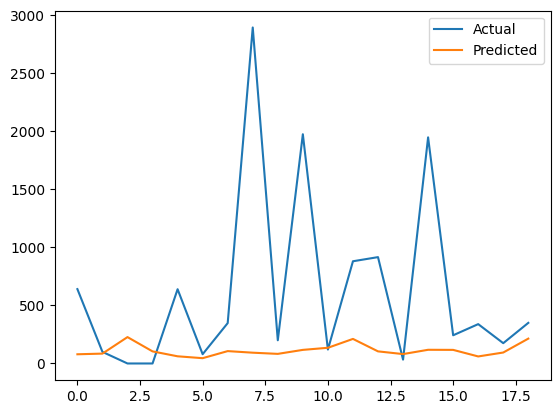

Final MAE: 554.6


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error


df = pd.read_csv('expense_data.csv')

df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df['Amount'] = pd.to_numeric(df['Amount'], errors='coerce')

df = df.dropna(subset=['Date', 'Amount', 'Income/Expense'])

df = df[df['Income/Expense'].str.lower() == 'expense']

daily = df.groupby(df['Date'].dt.date)['Amount'].sum()

dates = pd.date_range(min(daily.index), max(daily.index))
daily = daily.reindex(dates, fill_value=0)

data = np.log1p(daily.values)


def create_dataset(data, window=7):
    X, y = [], []
    for i in range(len(data) - window):
        X.append(data[i:i+window])
        y.append(data[i+window])
    return np.array(X), np.array(y)

window = 7
X, y = create_dataset(data, window)

# Train/Test split
split = int(len(X)*0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# =========================
# LightGBM Model
# =========================
model = LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)

# =========================
# Train with Early Stop (3%)
# =========================
best_mae = float('inf')

for i in range(1, 501):
    model.set_params(n_estimators=i)
    model.fit(X_train, y_train)

    pred_train = model.predict(X_train)
    pred_val = model.predict(X_test)

    train_mae = mean_absolute_error(y_train, pred_train)
    val_mae = mean_absolute_error(y_test, pred_val)

    diff = abs(train_mae - val_mae) / train_mae

    if diff <= 0.03:
        print(f"Stopped at iteration {i} (MAE diff ≤ 3%)")
        break

# =========================
# Final Prediction
# =========================
pred = model.predict(X_test)

# Convert back
pred = np.expm1(pred)
actual = np.expm1(y_test)

# =========================
# Plot
# =========================
plt.plot(actual, label='Actual')
plt.plot(pred, label='Predicted')
plt.legend()
plt.show()

# =========================
# Result
# =========================
mae = mean_absolute_error(actual, pred)
print("Final MAE:", round(mae, 2))